In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Para que los gráficos salgan dentro del notebook
%matplotlib inline

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "Data" / "quirofano_febrero_limpio.csv"

print("Base:", BASE_DIR)
print("CSV encontrado:", DATA_PATH.exists())
print("Ruta CSV:", DATA_PATH)

Base: c:\Users\dario\Desktop\UNIVERSIDAD\Ingenieria de la salud- UBU\HUBU\Proyecto_PR
CSV encontrado: True
Ruta CSV: c:\Users\dario\Desktop\UNIVERSIDAD\Ingenieria de la salud- UBU\HUBU\Proyecto_PR\Data\quirofano_febrero_limpio.csv


In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["fecha", "inicio_dt", "fin_dt"])
df.head()

,paciente_id,servicio,quirofano,centro,fecha,hora_inicio,hora_fin,anestesia,ambulatorio,tipo_caso,...,suspendida,motivo_suspension,provincia,sector,inicio_dt,fin_dt,duracion_min,duracion_horas,es_urgencia,esta_suspendida
0,463696,CGD,QE5,HOSPITAL UNIVERSITARIO DE BURGOS,2026-02-01,11:15,12:40,GENERAL,N,U,...,N,NaN,BURGOS,9-Desconocido,2026-02-01 11:15:00,2026-02-01 12:40:00,85.0,1.416667,True,False
1,357362,CGD,QE5,HOSPITAL UNIVERSITARIO DE BURGOS,2026-02-02,23:00,00:00,GENERAL,N,U,...,N,NaN,BURGOS,9-Desconocido,2026-02-02 23:00:00,2026-02-03 00:00:00,60.0,1.000000,True,False
2,164087,CGD,QE5,HOSPITAL UNIVERSITARIO DE BURGOS,2026-02-02,16:50,17:20,LOCAL MAS SEDACION,N,P,...,N,NaN,BURGOS,9-Desconocido,2026-02-02 16:50:00,2026-02-02 17:20:00,30.0,0.500000,False,False
3,608859,CGD,QE5,HOSPITAL UNIVERSITARIO DE BURGOS,2026-02-02,13:15,14:25,GENERAL,N,P,...,N,NaN,BURGOS,9-Desconocido,2026-02-02 13:15:00,2026-02-02 14:25:00,70.0,1.166667,False,False
4,115207,CGD,QE5,HOSPITAL UNIVERSITARIO DE BURGOS,2026-02-02,15:35,16:40,INTRADURAL,N,P,...,N,NaN,BURGOS,9-Desconocido,2026-02-02 15:35:00,2026-02-02 16:40:00,65.0,1.083333,False,False


In [3]:
df_real = df[df["esta_suspendida"] == False].copy()

print("Total registros:", len(df))
print("Cirugías reales:", len(df_real))
print("Urgencias reales:", int(df_real["es_urgencia"].sum()))
print("Quirófanos utilizados:", df_real["quirofano"].nunique())

Total registros: 286
Cirugías reales: 240
Urgencias reales: 53
Quirófanos utilizados: 8


In [4]:
resumen = pd.DataFrame([{
    "cirugías_reales": len(df_real),
    "urgencias": int(df_real["es_urgencia"].sum()),
    "quirofanos_utilizados": int(df_real["quirofano"].nunique()),
    "duracion_media_min": round(df_real["duracion_min"].mean(), 2),
    "duracion_mediana_min": round(df_real["duracion_min"].median(), 2),
}])

resumen

,cirugías_reales,urgencias,quirofanos_utilizados,duracion_media_min,duracion_mediana_min
0,240,53,8,97.95,75.0


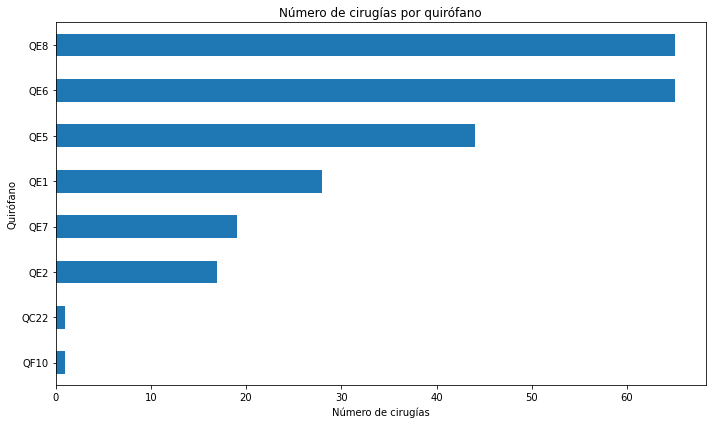

In [5]:
uso_qx = df_real["quirofano"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
uso_qx.plot(kind="barh")
plt.title("Número de cirugías por quirófano")
plt.xlabel("Número de cirugías")
plt.ylabel("Quirófano")
plt.tight_layout()
plt.show()

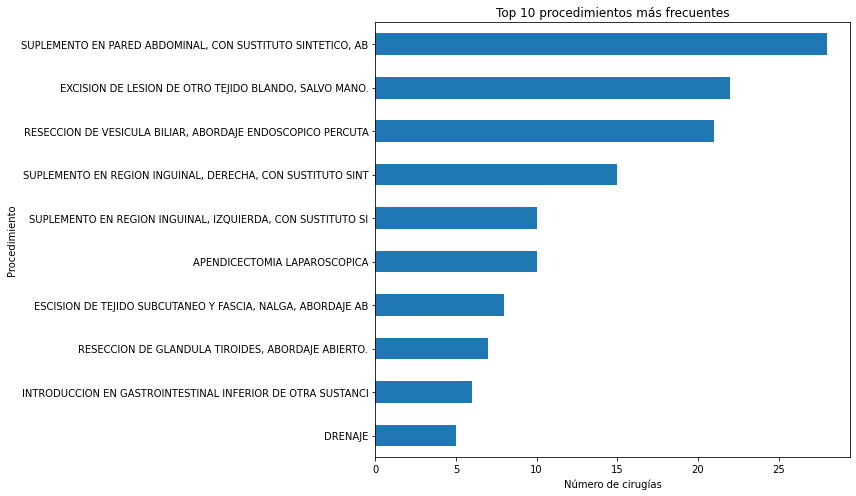

In [6]:
top_proc = (
    df_real["procedimiento"]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 7))
top_proc.plot(kind="barh")
plt.title("Top 10 procedimientos más frecuentes")
plt.xlabel("Número de cirugías")
plt.ylabel("Procedimiento")
plt.tight_layout()
plt.show()

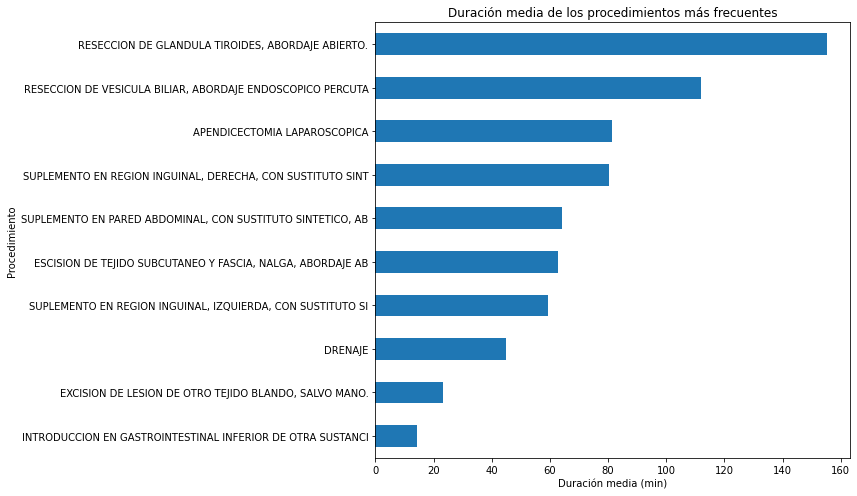

In [7]:
dur_proc = (
    df_real[df_real["procedimiento"].isin(top_proc.index)]
    .groupby("procedimiento")["duracion_min"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 7))
dur_proc.plot(kind="barh")
plt.title("Duración media de los procedimientos más frecuentes")
plt.xlabel("Duración media (min)")
plt.ylabel("Procedimiento")
plt.tight_layout()
plt.show()

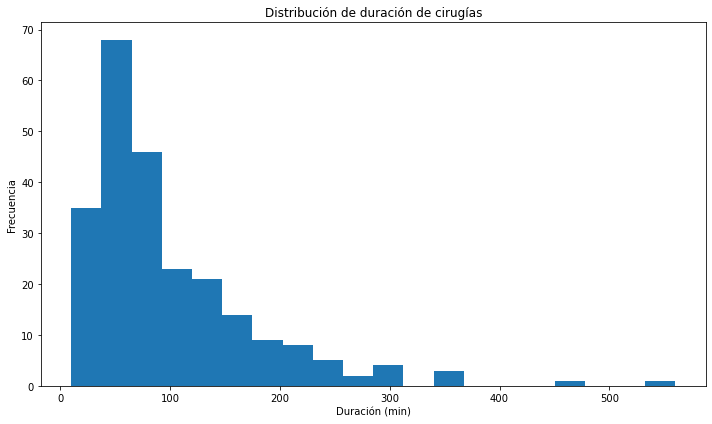

In [8]:
plt.figure(figsize=(10, 6))
plt.hist(df_real["duracion_min"].dropna(), bins=20)
plt.title("Distribución de duración de cirugías")
plt.xlabel("Duración (min)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [9]:
df_gap = df_real.sort_values(["quirofano", "fecha", "inicio_dt"]).copy()

df_gap["fin_anterior"] = df_gap.groupby(["quirofano", "fecha"])["fin_dt"].shift(1)
df_gap["tiempo_muerto_min"] = (
    df_gap["inicio_dt"] - df_gap["fin_anterior"]
).dt.total_seconds() / 60

tiempo_medio = df_gap["tiempo_muerto_min"].dropna().mean()
print("Tiempo muerto medio real entre cirugías (mismo día):", round(tiempo_medio, 2), "min")

Tiempo muerto medio real entre cirugías (mismo día): 52.33 min


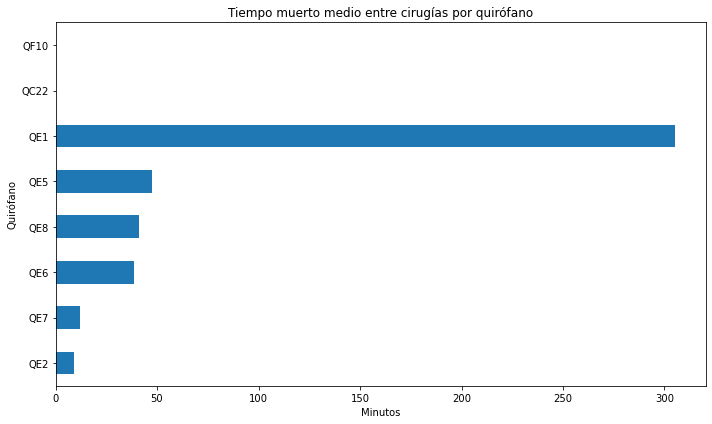

In [10]:
gap_por_qx = (
    df_gap.groupby("quirofano")["tiempo_muerto_min"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
gap_por_qx.plot(kind="barh")
plt.title("Tiempo muerto medio entre cirugías por quirófano")
plt.xlabel("Minutos")
plt.ylabel("Quirófano")
plt.tight_layout()
plt.show()

In [11]:
tabla_proc = (
    df_real.groupby("procedimiento")
    .agg(
        n_cirugias=("procedimiento", "count"),
        duracion_media=("duracion_min", "mean"),
        duracion_mediana=("duracion_min", "median"),
        desviacion=("duracion_min", "std")
    )
    .sort_values("n_cirugias", ascending=False)
    .head(15)
    .round(2)
)

tabla_proc

,n_cirugias,duracion_media,duracion_mediana,desviacion
procedimiento,,,,
"SUPLEMENTO EN PARED ABDOMINAL, CON SUSTITUTO SINTETICO, AB",28,64.00,60.0,28.13
"EXCISION DE LESION DE OTRO TEJIDO BLANDO, SALVO MANO.",22,23.09,20.0,8.16
"RESECCION DE VESICULA BILIAR, ABORDAJE ENDOSCOPICO PERCUTA",21,112.00,110.0,42.61
"SUPLEMENTO EN REGION INGUINAL, DERECHA, CON SUSTITUTO SINT",15,80.33,75.0,34.35
"SUPLEMENTO EN REGION INGUINAL, IZQUIERDA, CON SUSTITUTO SI",10,59.50,60.0,10.12
APENDICECTOMIA LAPAROSCOPICA,10,81.50,80.0,9.44
"ESCISION DE TEJIDO SUBCUTANEO Y FASCIA, NALGA, ABORDAJE AB",8,62.88,60.0,19.39
"RESECCION DE GLANDULA TIROIDES, ABORDAJE ABIERTO.",7,155.29,150.0,49.55
INTRODUCCION EN GASTROINTESTINAL INFERIOR DE OTRA SUSTANCI,6,14.17,15.0,3.76


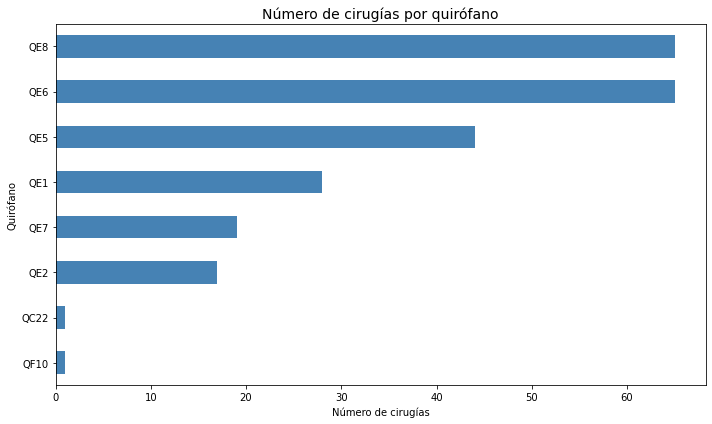

In [12]:
plt.figure(figsize=(10, 6))
uso_qx.plot(kind="barh", color="steelblue")
plt.title("Número de cirugías por quirófano", fontsize=14)
plt.xlabel("Número de cirugías")
plt.ylabel("Quirófano")
plt.tight_layout()
plt.show()

In [1]:
from Proyecto.analisis_quirofano import (
    cargar_datos,
    preparar_dataset_funcional,
    construir_catalogo_quirurgico,
    estimar_nueva_cirugia
)

In [3]:
df = cargar_datos()
df_funcional = preparar_dataset_funcional(df)
catalogo = construir_catalogo_quirurgico(df_funcional)

catalogo.head(10)

,procedimiento_base,n_casos,duracion_media_min,duracion_mediana_min,desviacion_min,quirofanos_habituales,prep_min,post_min,buffer_variabilidad_min,duracion_planificable_min
0,"SUPLEMENTO EN PARED ABDOMINAL, CON SUSTITUTO S...",28,64.00,60.0,28.13,"QE1, QE5, QE6, QE8",15,10,14.0,99.0
1,"EXCISION DE LESION DE OTRO TEJIDO BLANDO, SALV...",22,23.09,20.0,8.16,"QE2, QE7",15,10,4.0,49.0
2,COLECISTECTOMIA LAPAROSCOPICA,21,112.00,110.0,42.61,"QE5, QE6, QE7, QE8",15,10,21.0,156.0
3,HERNIA INGUINAL DERECHA,15,80.33,75.0,34.35,"QE5, QE6, QE8",15,10,17.0,117.0
4,APENDICECTOMIA LAPAROSCOPICA,11,79.55,80.0,11.06,"QE1, QE5, QE8",15,10,6.0,111.0
5,HERNIA INGUINAL IZQUIERDA,10,59.50,60.0,10.12,"QE5, QE6, QE7, QE8",15,10,5.0,90.0
6,"ESCISION DE TEJIDO SUBCUTANEO Y FASCIA, NALGA,...",8,62.88,60.0,19.39,"QE5, QE6, QE8",15,10,10.0,95.0
7,"RESECCION DE GLANDULA TIROIDES, ABORDAJE ABIERTO.",7,155.29,150.0,49.55,"QE2, QE6, QE7, QE8",15,10,25.0,200.0
8,INTRODUCCION EN GASTROINTESTINAL INFERIOR DE O...,6,14.17,15.0,3.76,"QE6, QE8",15,10,2.0,42.0
9,DRENAJE,5,45.00,45.0,6.12,"QE1, QE2, QE8",15,10,3.0,73.0


In [4]:
estimacion = estimar_nueva_cirugia(catalogo, "APENDICECTOMIA LAPAROSCOPICA")
estimacion

{'procedimiento': 'APENDICECTOMIA LAPAROSCOPICA',
 'n_casos_historicos': 11,
 'duracion_mediana_min': 80.0,
 'prep_min': 15.0,
 'post_min': 10.0,
 'buffer_variabilidad_min': 6.0,
 'duracion_planificable_min': 111.0,
 'quirofanos_habituales': 'QE1, QE5, QE8'}

In [5]:
import pandas as pd

pd.DataFrame([estimacion]).T.rename(columns={0: "valor"})

,valor
procedimiento,APENDICECTOMIA LAPAROSCOPICA
n_casos_historicos,11
duracion_mediana_min,80.0
prep_min,15.0
post_min,10.0
buffer_variabilidad_min,6.0
duracion_planificable_min,111.0
quirofanos_habituales,"QE1, QE5, QE8"


In [6]:
procedimientos_prueba = [
    "APENDICECTOMIA LAPAROSCOPICA",
    "COLECISTECTOMIA LAPAROSCOPICA",
    "HERNIA INGUINAL DERECHA"
]

resultados = [estimar_nueva_cirugia(catalogo, p) for p in procedimientos_prueba]
pd.DataFrame(resultados)

,procedimiento,n_casos_historicos,duracion_mediana_min,prep_min,post_min,buffer_variabilidad_min,duracion_planificable_min,quirofanos_habituales
0,APENDICECTOMIA LAPAROSCOPICA,11,80.0,15.0,10.0,6.0,111.0,"QE1, QE5, QE8"
1,COLECISTECTOMIA LAPAROSCOPICA,21,110.0,15.0,10.0,21.0,156.0,"QE5, QE6, QE7, QE8"
2,HERNIA INGUINAL DERECHA,15,75.0,15.0,10.0,17.0,117.0,"QE5, QE6, QE8"


In [1]:
from Proyecto.analisis_quirofano import (
    cargar_datos,
    preparar_dataset_funcional,
    construir_catalogo_quirurgico,
    proponer_hueco
)

df = cargar_datos()
df_real = preparar_dataset_funcional(df)

catalogo = construir_catalogo_quirurgico(df_real)

proponer_hueco(
    df_real,
    catalogo,
    "APENDICECTOMIA LAPAROSCOPICA",
    "2026-02-02"
)

{'quirofano': 'QE5',
 'inicio': Timestamp('2026-02-02 17:20:00'),
 'fin_estimado': Timestamp('2026-02-02 19:11:00'),
 'duracion_disponible': 340.0}

In [1]:
from Proyecto.analisis_quirofano import (
    cargar_datos,
    preparar_dataset_funcional,
    construir_catalogo_quirurgico,
    proponer_hueco
)

df = cargar_datos()
df_real = preparar_dataset_funcional(df)
catalogo = construir_catalogo_quirurgico(df_real)

proponer_hueco(
    df_real=df_real,
    catalogo=catalogo,
    procedimiento="APENDICECTOMIA LAPAROSCOPICA",
    fecha="2026-02-02",
    hora_inicio_bloque="08:00",
    hora_fin_bloque="20:00",
    quirofanos_validos=["QE1", "QE2", "QE5", "QE6", "QE7", "QE8"]
)

TypeError: proponer_hueco() got an unexpected keyword argument 'hora_inicio_bloque'